In [21]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt

# Isolation Forest

## Generación de datos de ejemplo

In [7]:
# Generamos dos clusters al azar con distribuciones gaussianas 2D (una elongada) alrededor de un centro, y outliers al distribuidos al azar
n_samples, n_outliers = 120, 40
rng = np.random.RandomState(0)
covariance = np.array([[0.5, -0.1], [0.7, 0.4]])
cluster_1 = 0.4 * rng.randn(n_samples, 2) @ covariance + np.array([2, 2])  # general
cluster_2 = 0.3 * rng.randn(n_samples, 2) + np.array([-2, -2])  # spherical
outliers = rng.uniform(low=-4, high=4, size=(n_outliers, 2))
X = np.concatenate([cluster_1, cluster_2, outliers])
y = np.concatenate([np.ones((2 * n_samples), dtype=int), -np.ones((n_outliers), dtype=int)])
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

## Graficamos los datos

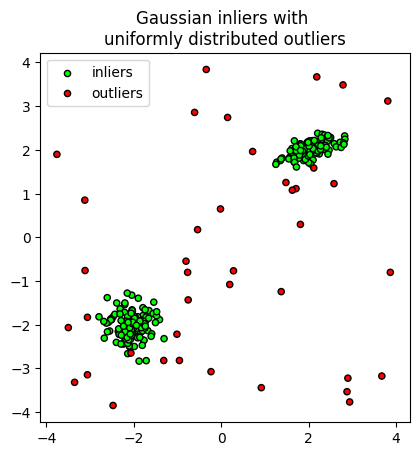

In [17]:
colors = ["lime" if c == 1 else "red" for c in y]
plt.scatter(X[:, 0], X[:, 1], c=colors, s=20, edgecolor="k")
sc1 = plt.scatter([], [], c="lime", s=20, edgecolor="k", label="inliers")
sc2 = plt.scatter([], [], c="red", s=20, edgecolor="k", label="outliers")
plt.axis("square")
plt.legend(handles=[sc1, sc2])
plt.title("Gaussian inliers with \nuniformly distributed outliers")
plt.show()

## Calcular IsolationForest

In [39]:
isol_forest = IsolationForest(max_samples=100, random_state=0)
isol_forest.fit(X_train)
predicted_y = isol_forest.predict(X_test)
acc = 100 * np.sum(y_test == predicted_y)/len(X_test)
print(f"{acc:.1f}% identificado correctamente")

92.9% identificado correctamente


## Graficar el resultado (todos los puntos)

<Figure size 640x480 with 0 Axes>

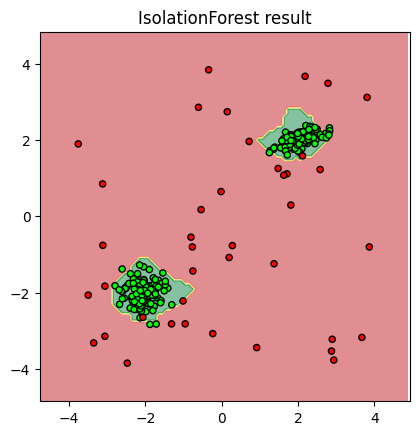

In [45]:
pred_y_all = isol_forest.predict(X)
plt.figure()
disp = DecisionBoundaryDisplay.from_estimator(isol_forest, X, response_method="predict", alpha=0.5, cmap="RdYlGn")
colors = ["lime" if c == 1 else "red" for c in y]
disp.ax_.scatter(X[:, 0], X[:, 1], c=colors, s=20, edgecolor="k")
disp.ax_.set_title("IsolationForest result")
plt.axis("square")
plt.show()